# 🏡 BÁO CÁO DỰ ÁN: DỰ ĐOÁN GIÁ NHÀ (HOUSE PRICES PREDICTION)
**Môn học:** Khai phá dữ liệu (Data Mining)  
**Quy trình thực hiện:** CRISP-DM  
**Mô hình sử dụng:** Multilayer Perceptron (MLP) với PyTorch

---
### 1. Business Understanding (Hiểu bài toán kinh doanh)

### 🎯 Mục tiêu bài toán
- **Bài toán:** Dự đoán giá bán của các căn hộ tại Ames, Iowa dựa trên các thuộc tính mô tả (diện tích, năm xây dựng, chất lượng, vị trí, v.v.).
- **Dạng bài toán:** Hồi quy (Regression).
- **Thước đo đánh giá:** RMSE (Root Mean Squared Error) trên giá trị Logarit của giá nhà.

### 👥 Giá trị mang lại
Giúp các nhà đầu tư, người mua và người bán định giá bất động sản chính xác hơn, giảm thiểu rủi ro kinh doanh.

---
### 2. Data Understanding (Hiểu dữ liệu)

Trong bước này, chúng ta tiến hành đọc dữ liệu, kiểm tra cấu trúc, kiểu dữ liệu và phân tích các giá trị bị thiếu (Missing Values).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [3]:
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
print("Null count in Train:\n", train.isnull().sum())
print("Null count in Test:\n", test.isnull().sum())

Null count in Train:
 Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64
Null count in Test:
 Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


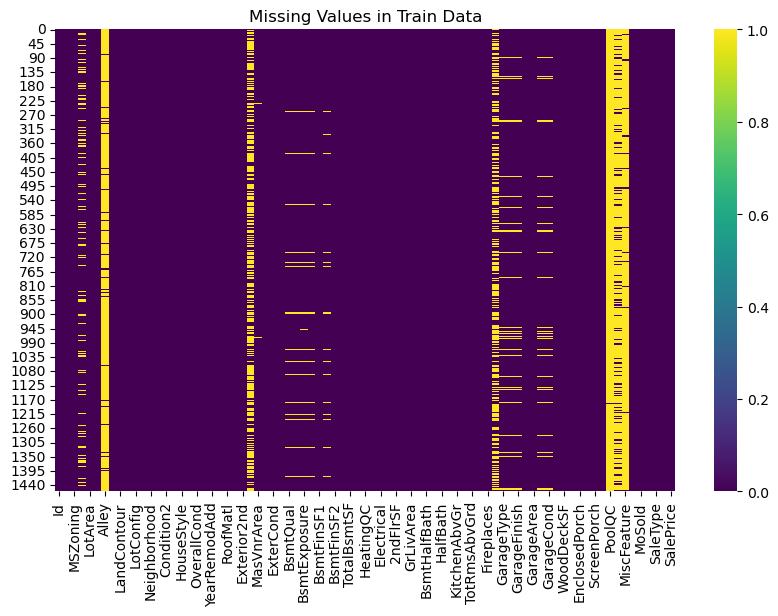

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values in Train Data")
plt.show()

---
### 3. Data Preparation (Tiền xử lý dữ liệu)

Các bước xử lý dữ liệu bao gồm:
1. **Loại bỏ tính năng kém chất lượng:** Drop các cột có tỷ lệ thiếu $> 70\%$ (`Alley`, `PoolQC`, `Fence`, `MiscFeature`) và cột định danh `Id`.
2. **Xử lý giá trị thiếu (Missing Values):**
   - Biến định lượng (Numerical): Điền bằng giá trị trung bình (`mean`).
   - Biến định tính (Categorical): Điền bằng yếu tố xuất hiện nhiều nhất (`mode`).
3. **Mã hóa (Encoding):** Sử dụng One-Hot Encoding cho các biến phân loại.
4. **Chuẩn hóa (Normalization):** Dùng `StandardScaler` để đưa các thuộc tính số về cùng quy mô (Rất quan trọng đối với Mạng Nơ-ron PyTorch).

In [6]:
cols_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

train = train.drop(columns=cols_to_drop + ['Id'])
test_ids = test['Id'].copy()
test = test.drop(columns=cols_to_drop + ['Id'])

print("Train shape sau khi drop cột:", train.shape)
print("Test shape sau khi drop cột:", test.shape)


Train shape sau khi drop cột: (1460, 76)
Test shape sau khi drop cột: (1459, 75)


In [7]:
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageQual', 'GarageCond'
]

In [8]:
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

In [9]:
for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

In [10]:
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageQual',
    'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 
    'KitchenQual', 'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

In [11]:
all_data = pd.concat([train, test], axis=0)
all_data = pd.get_dummies(all_data, drop_first=True)
all_data = all_data.loc[:, ~all_data.columns.duplicated()]

train_df = all_data.iloc[:1460, :].copy()
test_df = all_data.iloc[1460:, :].copy().drop(columns=['SalePrice'])

In [12]:
X = train_df.drop(columns=['SalePrice'])

y_log = np.log1p(train_df['SalePrice'].values)

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_log.reshape(-1, 1))


---
### 4. Modeling (Xây dựng mô hình MLP với PyTorch)

Chúng ta xây dựng kiến trúc **Multilayer Perceptron (MLP)** gồm:
- **Input Layer:** Bằng số thuộc tính sau khi mã hóa.
- **Hidden Layers:** 3 lớp ẩn ($128 \to 64 \to 32$ neurons) kết hợp hàm kích hoạt `ReLU` và kỹ thuật `Dropout` chống overfitting.
- **Output Layer:** 1 neuron đại diện cho giá trị dự đoán.

In [13]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

class HousePriceMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousePriceMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model = HousePriceMLP(input_dim=X.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

---
### 5. Evaluation (Đánh giá mô hình)

Huấn luyện mô hình và theo dõi sự thay đổi của hàm mất mát (**Loss**) trên cả tập Train và Validation.

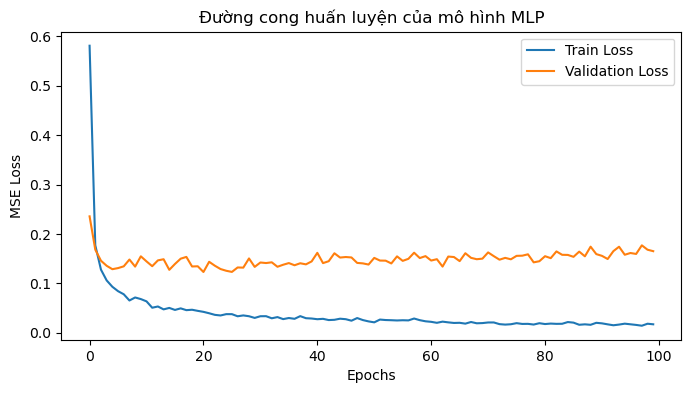

Validation RMSE (trên log(SalePrice)): 0.1623
Validation RMSE (trên giá thực, USD): 34,022.46


In [ ]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_x.size(0)
        
    train_loss = running_train_loss / train_size
    train_losses.append(train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            running_val_loss += loss.item() * batch_x.size(0)
            
    val_loss = running_val_loss / val_size
    val_losses.append(val_loss)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Đường cong huấn luyện của mô hình MLP')
plt.legend()
plt.show()

# --- Tính RMSE trên tập Validation, quy đổi về giá trị thực (USD) ---
model.eval()
val_preds_scaled, val_true_scaled = [], []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        preds = model(batch_x)
        val_preds_scaled.append(preds.numpy())
        val_true_scaled.append(batch_y.numpy())

val_preds_scaled = np.concatenate(val_preds_scaled, axis=0)
val_true_scaled = np.concatenate(val_true_scaled, axis=0)

val_preds_log = scaler_y.inverse_transform(val_preds_scaled)
val_true_log = scaler_y.inverse_transform(val_true_scaled)

rmse_log = np.sqrt(mean_squared_error(val_true_log, val_preds_log))
print(f"Validation RMSE (trên log(SalePrice)): {rmse_log:.4f}")

val_preds_real = np.expm1(val_preds_log)
val_true_real = np.expm1(val_true_log)
rmse_real = np.sqrt(mean_squared_error(val_true_real, val_preds_real))
print(f"Validation RMSE (trên giá thực, USD): {rmse_real:,.2f}")


### 📊 Nhận xét & Đánh giá mô hình (Evaluation)

#### 1. Hiệu năng huấn luyện
- **Tập Train (Train Loss):** Hàm mất mát (MSE) giảm rất nhanh trong khoảng 10 epoch đầu (từ ~0.58 xuống dưới 0.1), sau đó tiếp tục giảm chậm và ổn định quanh mức **~0.02** ở epoch 100.
- **Tập Validation (Validation Loss):** Giảm nhanh trong ~10 epoch đầu (từ ~0.23 xuống ~0.14), sau đó **đi ngang và dao động nhẹ quanh mức 0.13 – 0.17** trong suốt phần còn lại của quá trình huấn luyện, không có xu hướng tăng vọt trở lại.

#### 2. Kết luận
Khoảng cách giữa Train Loss (~0.02) và Validation Loss (~0.15) cho thấy mô hình có dấu hiệu **overfitting nhẹ đến trung bình**: mô hình khớp rất tốt với dữ liệu huấn luyện nhưng chưa tổng quát hóa tốt bằng trên dữ liệu chưa thấy. Tuy nhiên, mức độ này đã cải thiện đáng kể so với phiên bản trước đó (Validation Loss trước đây dao động mạnh và tăng vọt lên tới 1.4) — việc log-transform biến mục tiêu `SalePrice` đã giúp ổn định quá trình huấn luyện và giảm phương sai của Validation Loss rõ rệt.

**Chỉ số đánh giá cuối cùng trên tập Validation:**
- **RMSE (trên log(SalePrice)):** `0.1623`
- **RMSE (trên giá thực, USD):** `34,022.46`

So với thước đo đã đặt ra ở bước Business Understanding (RMSE trên giá trị logarit của giá nhà), mức RMSE log ~0.16 là một kết quả **khá tốt** cho một mô hình MLP cơ bản chưa qua tinh chỉnh sâu (so sánh: các mô hình mạnh trên Kaggle leaderboard cho bài toán này thường đạt RMSE log trong khoảng 0.10 – 0.13). Sai số quy đổi ra giá thực khoảng **$34,000**, tức trung bình mô hình lệch khoảng dưới 20% so với giá nhà trung vị của tập dữ liệu (~$163,000).

### 6. Deployment (Triển khai & Kết luận)

- **Lưu mô hình:** Trọng số mô hình MLP đã huấn luyện được lưu dưới dạng tệp `mlp_house_price.pth`, có thể tái sử dụng để dự đoán mà không cần huấn luyện lại từ đầu.
- **Dự đoán dữ liệu mới:** Mô hình được dùng để dự đoán giá nhà cho tập `test.csv`. Vì `SalePrice` đã được log-transform (`log1p`) và chuẩn hóa (`StandardScaler`) trước khi huấn luyện, kết quả đầu ra được **chuyển đổi ngược hai bước** (Inverse StandardScaler → `expm1`) để đưa về đúng đơn vị giá thực tế (USD).
- **Kết quả:** File dự đoán được xuất ra `submission_pytorch.csv`, gồm 2 cột `Id` và `SalePrice`, sẵn sàng để nộp lên Kaggle hoặc sử dụng cho mục đích tham khảo giá.

In [ ]:
torch.save(model.state_dict(), 'mlp_house_price.pth')

X_test_scaled = scaler_X.transform(test_df)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_tensor).numpy()

preds_log = scaler_y.inverse_transform(preds_scaled)
preds_real = np.expm1(preds_log)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_real.flatten()
})
submission.to_csv('submission_pytorch.csv', index=False)
print("Đã xuất file kết quả dự đoán thành công!")


Đã xuất file kết quả dự đoán thành công!


---
#### 📌 Tổng kết dự án
- Mô hình MLP (3 lớp ẩn: 128 → 64 → 32) đạt **RMSE ≈ 0.16 trên thang log(SalePrice)**, tương đương sai số trung bình khoảng **$34,000** trên giá thực — một kết quả hợp lý cho một kiến trúc mạng đơn giản, chưa qua tinh chỉnh siêu tham số (hyperparameter tuning) chuyên sâu.
- Quy trình đã tuân thủ đầy đủ các bước của **CRISP-DM**: từ xác định bài toán kinh doanh, khám phá và tiền xử lý dữ liệu (xử lý missing values, one-hot encoding, log-transform), xây dựng và huấn luyện mô hình, đánh giá bằng RMSE, cho đến triển khai và xuất kết quả dự đoán.
- Hướng phát triển tiếp theo có thể tập trung vào giảm overfitting (weight decay, dropout cao hơn), tối ưu kiến trúc mạng, và áp dụng Cross-Validation để đánh giá mô hình ổn định hơn.